In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
#Set style visualisasi
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (6, 6)

In [4]:
ratings = pd.read_csv('ratingss.csv')
movies = pd.read_csv('moviess.csv')

MemoryError: Unable to allocate 572. MiB for an array with shape (3, 25000095) and data type int64

In [6]:
#Load dataset ratings dengan komposisi 50% dari jumlah 25jt baris menjadi 12,5jt
ratings = pd.read_csv('ratingss.csv', nrows=12500000) 

In [25]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [7]:
#load dataset movies
movies = pd.read_csv('moviess.csv')

In [26]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [8]:
#Informasi jumlah dataset ratings dan movies
print(f"Jumlah data ratings: {len(ratings)}")
print(f"Jumlah data movies: {len(movies)}")

Jumlah data ratings: 12500000
Jumlah data movies: 62423


In [9]:
#Informasi dataset ratings
print("Info Ratings:")
print(ratings.info())

Info Ratings:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500000 entries, 0 to 12499999
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 381.5 MB
None


In [10]:
#Informasi dataset movies
print("Info Movies:")
print(movies.info())

Info Movies:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62423 entries, 0 to 62422
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  62423 non-null  int64 
 1   title    62423 non-null  object
 2   genres   62423 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.4+ MB
None


In [11]:
#Cek missing values 
print("\nCek missing value ratings:")
print(ratings.isnull().sum())

print("\nCek missing value movies:")
print(movies.isnull().sum())


Cek missing value ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Cek missing value movies:
movieId    0
title      0
genres     0
dtype: int64


In [12]:
#Cek duplikasi data
print("\nCek duplikat:")
print(f"Duplikat ratings: {ratings.duplicated().sum()}")
print(f"Duplikat movies: {movies.duplicated().sum()}")


Cek duplikat:
Duplikat ratings: 0
Duplikat movies: 0


C:\Users\kaisy\AppData\Local\Temp\ipykernel_3176\1050801100.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ratings, x='rating', palette='viridis')


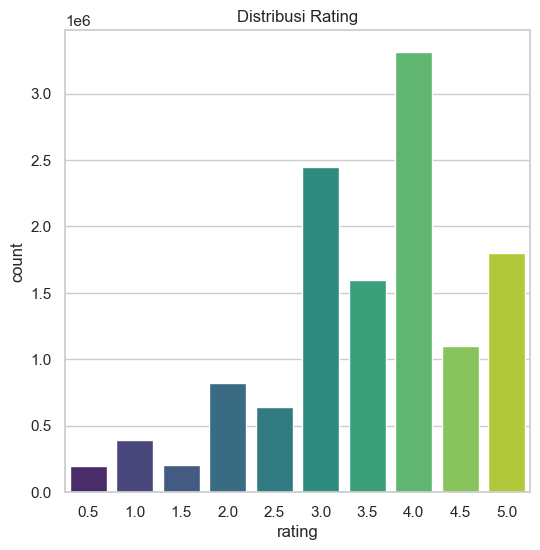

In [13]:
#Visualisasi dari distribusi ratings
sns.countplot(data=ratings, x='rating', palette='viridis')
plt.title('Distribusi Rating')
plt.show()

C:\Users\kaisy\AppData\Local\Temp\ipykernel_3176\4114794824.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_df, x='Jumlah', y='Genre', palette='coolwarm')


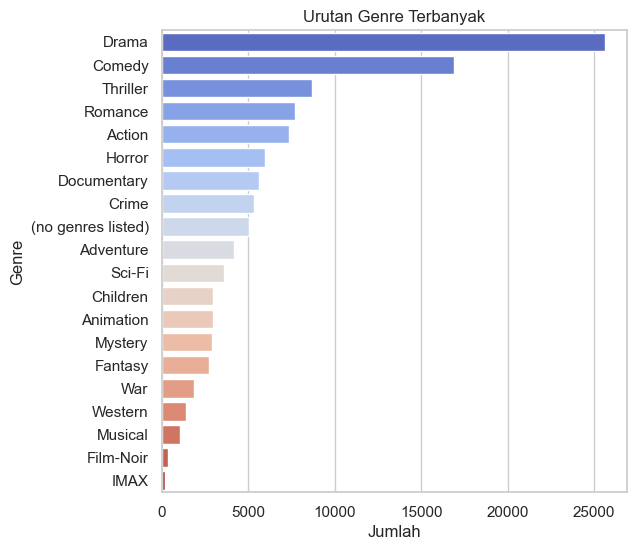

In [14]:
#Visualisasi genre terbanyak (paling populer)
from collections import Counter
genre_list = movies['genres'].str.split('|').sum()
genre_count = Counter(genre_list)
genre_df = pd.DataFrame(genre_count.items(), columns=['Genre', 'Jumlah']).sort_values(by='Jumlah', ascending=False)
sns.barplot(data=genre_df, x='Jumlah', y='Genre', palette='coolwarm')
plt.title('Urutan Genre Terbanyak')
plt.show()

In [15]:
#Merge dataset (ratings + movies)
df = ratings.merge(movies, on='movieId')

In [16]:
#Encode user dan movie
user_enc = LabelEncoder()
movie_enc = LabelEncoder()

df['user'] = user_enc.fit_transform(df['userId'])
df['movie'] = movie_enc.fit_transform(df['movieId'])
df['rating'] = df['rating'].astype(np.float32)

num_users = df['user'].nunique()
num_movies = df['movie'].nunique()

X = df[['user', 'movie']].values
y = df['rating'].values

In [17]:
#split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
#Bangun model NCF (Neural Collaborative Filtering)
from tensorflow.keras import Model, layers

class NCFModel(Model):
    def __init__(self, num_users, num_movies, embedding_size=100):
        super().__init__()
        self.user_embedding = layers.Embedding(num_users, embedding_size)
        self.movie_embedding = layers.Embedding(num_movies, embedding_size)

        self.dense1 = layers.Dense(128, activation='relu')
        self.dropout1 = layers.Dropout(0.3)
        self.dense2 = layers.Dense(64, activation='relu')
        self.dropout2 = layers.Dropout(0.3)
        self.dense3 = layers.Dense(32, activation='relu')
        self.output_layer = layers.Dense(1)

    def call(self, inputs):
        user_vec = self.user_embedding(inputs[:, 0])
        movie_vec = self.movie_embedding(inputs[:, 1])
        x = tf.concat([user_vec, movie_vec], axis=1)
        x = self.dense1(x)
        x = self.dropout1(x)
        x = self.dense2(x)
        x = self.dropout2(x)
        x = self.dense3(x)
        return self.output_layer(x)

In [24]:
#Training model 
model = NCFModel(num_users, num_movies)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=1024)

Epoch 1/5
9766/9766 [==============================] - 1281s 131ms/step - loss: 0.8098 - mae: 0.6841 - val_loss: 0.7453 - val_mae: 0.6697
Epoch 2/5
9766/9766 [==============================] - 1178s 121ms/step - loss: 0.6891 - mae: 0.6318 - val_loss: 0.7258 - val_mae: 0.6612
Epoch 3/5
9766/9766 [==============================] - 1874s 192ms/step - loss: 0.6603 - mae: 0.6173 - val_loss: 0.7011 - val_mae: 0.6462
Epoch 4/5
9766/9766 [==============================] - 1951s 200ms/step - loss: 0.6342 - mae: 0.6040 - val_loss: 0.6778 - val_mae: 0.6336
Epoch 5/5
9766/9766 [==============================] - 1206s 124ms/step - loss: 0.6110 - mae: 0.5919 - val_loss: 0.6769 - val_mae: 0.6374


In [28]:
!pip install tabulate

In [31]:
from tabulate import tabulate

def recommend_movies(user_id, top_k=5):
    encoded_user = user_enc.transform([user_id])[0]
    watched = df[df['userId'] == user_id]['movie'].unique()
    all_movies = df['movie'].unique()
    not_watched = np.setdiff1d(all_movies, watched)

    input_pairs = np.array([[encoded_user, m] for m in not_watched])
    predictions = model.predict(input_pairs, verbose=0).flatten()

    top_indices = predictions.argsort()[-top_k:][::-1]
    top_movie_ids = not_watched[top_indices]
    original_ids = movie_enc.inverse_transform(top_movie_ids)
    top_scores = predictions[top_indices]

    result = movies[movies['movieId'].isin(original_ids)][['title', 'genres']].reset_index(drop=True)
    result['predicted_rating'] = top_scores.round(3)

    print(f"\n🎬 Top {top_k} Rekomendasi Film untuk User {user_id}:\n")
    print(tabulate(result, headers='keys', tablefmt='pretty', showindex=True))

In [32]:
#Contoh rekomendasi film untuk user dengan id=1
recommend_movies(user_id=1)


🎬 Top 5 Rekomendasi Film untuk User 1:

+---+-------------------------------------------------------------------------+------------------+--------------------+
|   |                                  title                                  |      genres      |  predicted_rating  |
+---+-------------------------------------------------------------------------+------------------+--------------------+
| 0 | Heimat - A Chronicle of Germany (Heimat - Eine deutsche Chronik) (1984) |      Drama       | 4.263000011444092  |
| 1 |                   Mugabe and the White African (2009)                   |   Documentary    | 4.2170000076293945 |
| 2 |                         Band of Brothers (2001)                         | Action|Drama|War | 4.216000080108643  |
| 3 |                         Planet Earth II (2016)                          |   Documentary    | 4.209000110626221  |
| 4 |                            Obsession (1965)                             |      Comedy      | 4.206999778747559  |

In [33]:
#Contoh rekomendasi film untuk user dengan id=35
recommend_movies(user_id=35)


🎬 Top 5 Rekomendasi Film untuk User 35:

+---+-------------------------------------------------------------------------+--------------------+-------------------+
|   |                                  title                                  |       genres       | predicted_rating  |
+---+-------------------------------------------------------------------------+--------------------+-------------------+
| 0 |                        Home from the Hill (1960)                        |   Drama|Romance    | 4.289999961853027 |
| 1 | Heimat - A Chronicle of Germany (Heimat - Eine deutsche Chronik) (1984) |       Drama        | 4.28000020980835  |
| 2 |                            The Lorax (1972)                             | Animation|Children | 4.27400016784668  |
| 3 |                         Planet Earth II (2016)                          |    Documentary     | 4.269000053405762 |
| 4 |                            Obsession (1965)                             |       Comedy       | 4.25799989

In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

#prediksi rating dari model
y_pred = model.predict(X_test).flatten()

#metrik evaluasi
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

#hasil evaluasi
print("\n📈 Evaluasi Model:")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"Root Mean Squared Error  : {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score                 : {r2:.4f}")

78125/78125 [==============================] - 135s 2ms/step

📈 Evaluasi Model:
Mean Squared Error (MSE) : 0.6769
Root Mean Squared Error  : 0.8227
Mean Absolute Error (MAE): 0.6374
R² Score                 : 0.3990


In [35]:
model.export('model_ncf')

INFO:tensorflow:Assets written to: model_ncf\assets


INFO:tensorflow:Assets written to: model_ncf\assets


Saved artifact at 'model_ncf'. The following endpoints are available:

* Endpoint 'serve'
  Args:
    args_0: int64 Tensor, shape=(None, 2)
  Returns:
    float32 Tensor, shape=(None, 1)


In [37]:
converter = tf.lite.TFLiteConverter.from_saved_model('model_ncf')
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,      
    tf.lite.OpsSet.SELECT_TF_OPS         
]
converter.experimental_enable_resource_variables = True

In [38]:
#konversi model
tflite_model = converter.convert()

In [39]:
# Simpan model TFLite ke file
with open('ncf_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ Model berhasil disimpan sebagai 'model_ncf' dan dikonversi ke 'ncf_model.tflite'")

✅ Model berhasil disimpan sebagai 'model_ncf' dan dikonversi ke 'ncf_model.tflite'
